In [11]:
import boto3, random, base64, json, io
from PIL import Image, ImageDraw, ImageFont
ENDPOINT_NAME = 'YOLOv8-CFU-SageMaker-endpoint' 

In [12]:
def str_to_im(encoded_str):
    # Convert utf-8 string into a PIL image into a base 64 encoded jpeg in utf-8 format
    aux_path = '/tmp/tmp.png'
    with open(aux_path, 'wb') as f:
        f.write(base64.b64decode(encoded_str))
        f.close
    return Image.open(aux_path)

In [13]:
def im_to_str(PIL_im):
    # Convert a PIL image into a base 64 encoded jpeg in utf-8 format
    byte_arr = io.BytesIO()
    PIL_im.save(byte_arr, format='jpeg')
    return base64.b64encode(byte_arr.getvalue()).decode('utf-8')

In [14]:
# Read the image from file
orig_image = Image.open('cfu_positive.jpg')

In [15]:
# This cell will make a string to be used in the test event
im_to_str(orig_image)

'...'

In [6]:
# These are the steps that the lambda performs
# Break them down into individual cells and debug them seprately if needed

# Calculate the parameters for image resizing
image_height, image_width = orig_image.size
model_height, model_width = 640, 640
x_ratio = image_width/model_width
y_ratio = image_height/model_height

# Resize the image recieved to the size the model accepts
resizedImage = orig_image.resize((model_height, model_width), Image.Resampling.LANCZOS)

# Convert the image to the jpeg and save the jpeg as a byte stream 
img_byte_arr = io.BytesIO()
resizedImage.save(img_byte_arr, format='jpeg')

# Convert tyhe bytes intoe base64
payload = base64.b64encode(img_byte_arr.getvalue())

# Call the endpoint
runtime= boto3.client('runtime.sagemaker')
response = runtime.invoke_endpoint(EndpointName=ENDPOINT_NAME,
                                        ContentType='text/csv',
                                        Body=payload)
response_body = response['Body'].read()

# This i the result from the YOLO model
result = json.loads(response_body.decode('ascii'))

# Draw the boxes on the original image
if 'boxes' in result:
    draw = ImageDraw.Draw(orig_image) # Object PIL uses to draw aux lines and text
    for idx,(x1,y1,x2,y2,conf,lbl) in enumerate(result['boxes']):
        # Scale box coordinates back to the original image
        x1, x2 = int(x_ratio*x1), int(x_ratio*x2)
        y1, y2 = int(y_ratio*y1), int(y_ratio*y2)
        color = (random.randint(10,255), random.randint(10,255), random.randint(10,255))
        draw.rectangle(((x1,y1), (x2,y2)), outline = color)
        draw.text((x1,y1-40), f"Class: {int(lbl)}")
        draw.text((x1,y1-10), f"Conf: {int(conf*100)}")

# Make the resulting image with boxes into a string to be sent back via API
str_to_send_back = im_to_str(orig_image)

In [9]:
# Put here the string that your lambda function returns when running the test event
my_test_result = "..."

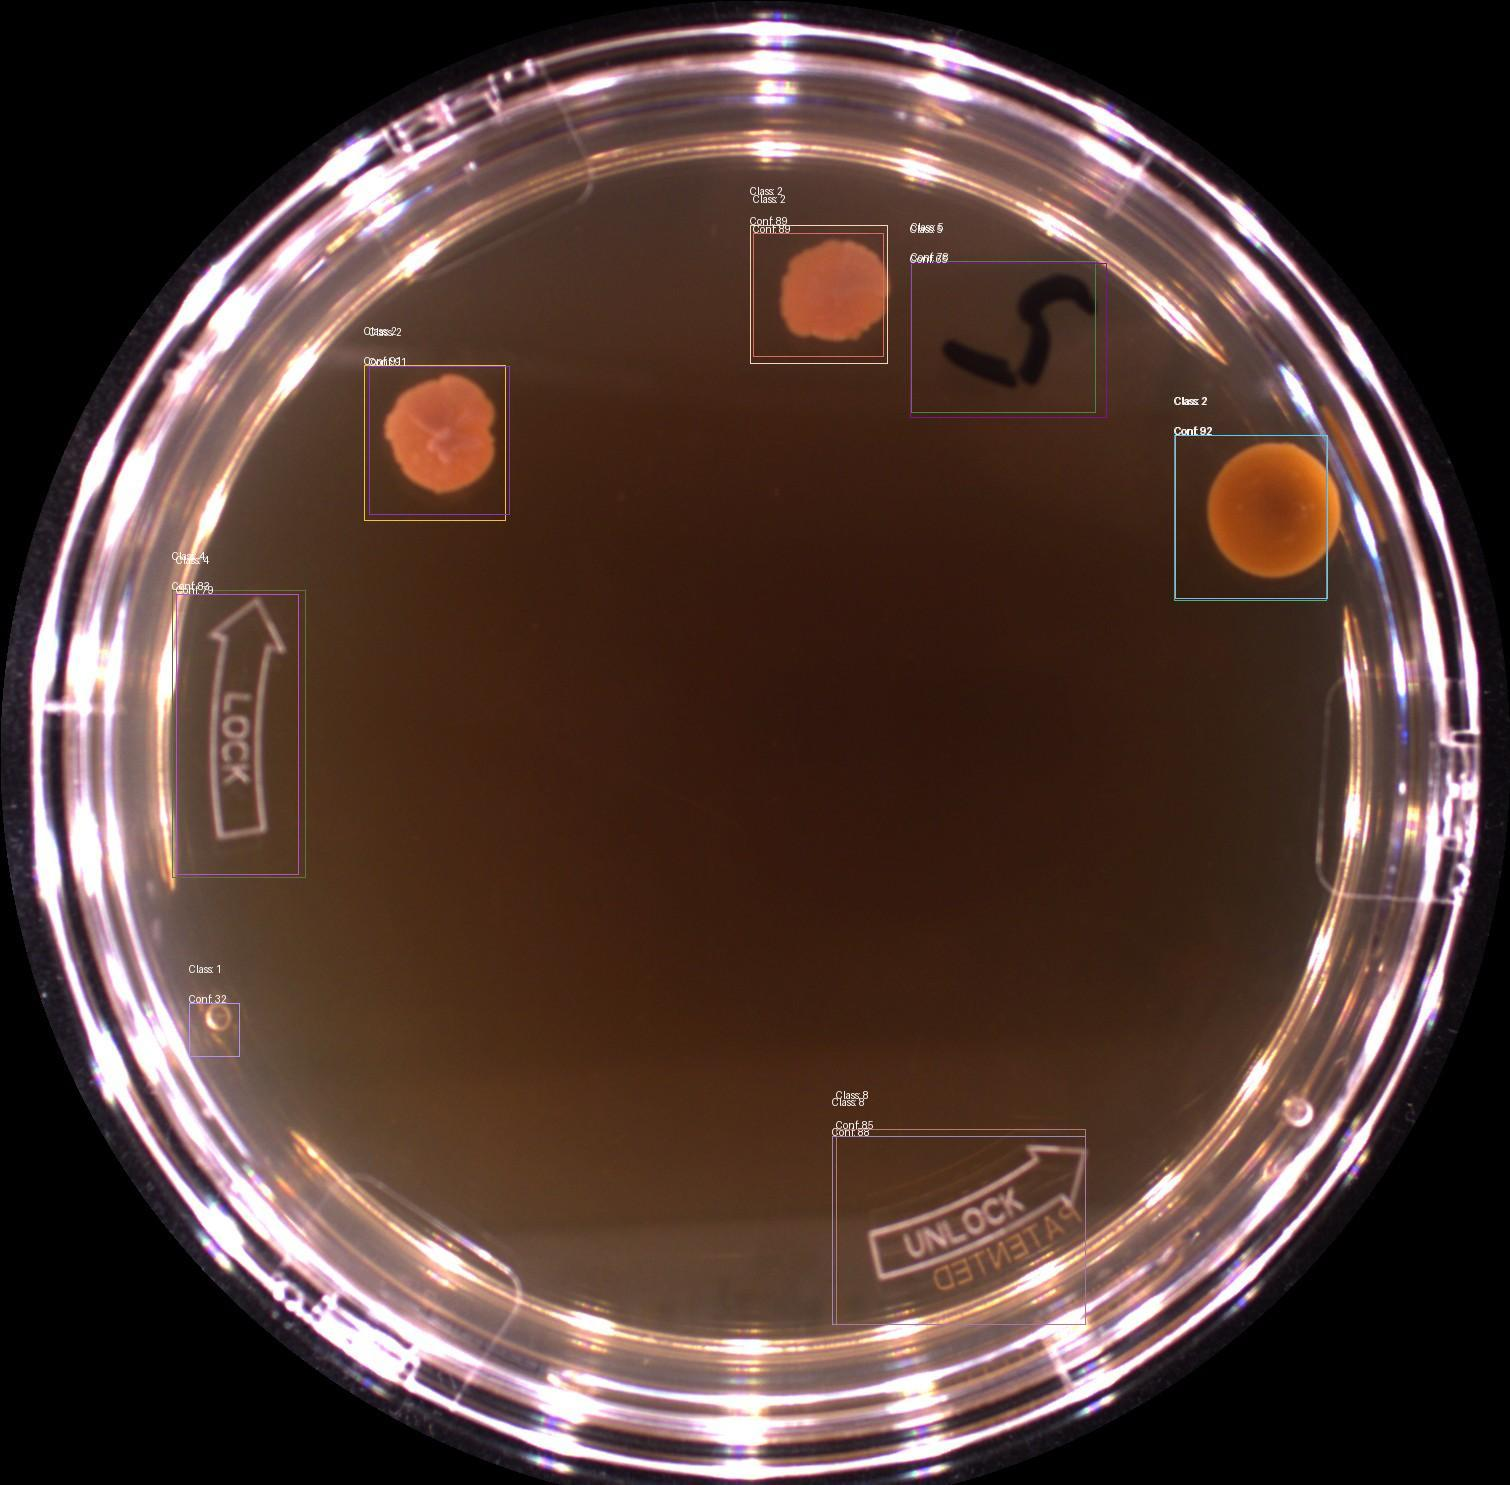

In [10]:
str_to_im(my_test_result)